## Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/Othercomputers/My Laptop/Work/Grievance Redressal Project')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [ ]:
df = pd.read_csv('data/No_PII_Grievance_Data_2.csv')

In [60]:
df.shape

(174479, 21)

In [61]:
df.columns

Index(['Unnamed: 0', 'grievance_id', 'citizen_id', 'citizen_gender',
       'grievance_text', 'language_code', 'final_department', 'final_category',
       'resolution_date', 'resolution_text', 'current_status',
       'portal_channel', 'attachment_id', 'feedback_date', 'feedback_text',
       'appeal_filed', 'appeal_id', 'appeal_date', 'appeal_reason',
       'appeal_resolution', 'officer_detail_who_closed_grievance'],
      dtype='object')

In [62]:
df = df.dropna(subset=['feedback_text'])
print(f"DataFrame shape after dropping nulls in 'feedback_text': {df.shape}")

DataFrame shape after dropping nulls in 'feedback_text': (80849, 21)


In [63]:
df = df[['grievance_id','feedback_text']]

## Data filtering and Preprocessing

In [64]:
# Ensure string type
df['feedback_text'] = df['feedback_text'].astype(str)

# ASCII pattern (allows English + numbers + common symbols)
pattern = r"^[\x00-\x7F]+$"

# Apply all filters
filtered_df = df[
    (df['feedback_text'].str.fullmatch(pattern, na=False)) &     # only ASCII (English)
    (df['feedback_text'].str.len() > 50)                      # len > 50
]

print(f"Done! Extracted {len(filtered_df)} rows.")

Done! Extracted 43139 rows.


In [65]:
display(filtered_df.sample(10))

,grievance_id,feedback_text
69320,DOPPW/E/2025/0008331,Not Satisfied The citizen says that his co...
151736,PRSEC/E/2025/0005077,On what basis the reference have been filed an...
65954,DOCAF/E/2025/0000692,Not satisfied // Complaint closed without reso...
7195,DARPG/E/2025/0000497,Know one solve my problem please contact me 93...
7391,DARPG/E/2025/0000921,Satisfied The citizen does not wish to provi...
25860,DOPPW/E/2025/0005486,The complainant says that all the documents ha...
18976,PMOPG/E/2025/0004217,THE NATIONAL INSURANCE COMPANY HAS MISGUIDED T...
88691,GOVUP/E/2025/0001709,The complaint is being forwarded to the person...
77060,DOPPW/E/2025/0003030,Satisfied/The citizen does not wish to provide...
95235,DOWCD/E/2025/0000391,not satisfied Nothing has happened and my comp...


In [66]:
filtered_grievance = filtered_df.copy()
print(f"Initialized filtered_grievance with shape: {filtered_grievance.shape}")

Initialized filtered_grievance with shape: (43139, 2)


In [67]:
filtered_grievance['feedback_text'] = filtered_grievance['feedback_text'].astype(str)
filtered_grievance['feedback_text_processed'] = filtered_grievance['feedback_text']

In [69]:
filtered_grievance['feedback_text_processed'] = filtered_grievance['feedback_text_processed'].str.lower()

In [70]:
import re

def remove_html_tags(text):
    if pd.isna(text):
        return text
    pattern = re.compile('<.*?>')
    return pattern.sub(r'', text)

filtered_grievance['feedback_text_processed'] = filtered_grievance['feedback_text_processed'].apply(remove_html_tags)

In [71]:
import re

def remove_url(text):
    if pd.isna(text):
        return text
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

filtered_grievance['feedback_text_processed'] = filtered_grievance['feedback_text_processed'].apply(remove_url)

In [72]:
import string
exclude = string.punctuation

def remove_punc_better(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', exclude))

filtered_grievance['feedback_text_processed'] = filtered_grievance['feedback_text_processed'].apply(remove_punc_better)

In [73]:
grievance_domain_data = filtered_grievance.copy()

# Display original shape
print(f"Original shape: {grievance_domain_data.shape}")

# Remove rows with duplicate feedback_text (keeps first occurrence)
df_deduplicated = grievance_domain_data.drop_duplicates(subset=['feedback_text'], keep='first')

# Display new shape
print(f"After deduplication shape: {df_deduplicated.shape}")
print(f"Duplicates removed: {grievance_domain_data.shape[0] - df_deduplicated.shape[0]}")

Original shape: (43139, 3)
After deduplication shape: (31533, 3)
Duplicates removed: 11606


In [74]:
display(df_deduplicated.sample(10))

,grievance_id,feedback_text,feedback_text_processed
99805,MOLBR/E/2025/0004038,"Not satisfied // wrong solution given, as the ...",not satisfied wrong solution given as the act...
3178,DOCAF/E/2025/0000089,IF YOU WANT YOUNG LADYS FOR SEX kindly call ad...,if you want young ladys for sex kindly call ad...
17726,PMOPG/D/2025/0014698,not satisfied/No action taken on complaint and...,not satisfiedno action taken on complaint and ...
97234,MINIT/E/2025/0000552,I would like to express my appreciation to the...,i would like to express my appreciation to the...
13662,CBOEC/E/2025/0000701,"Not satisfied - According to the citizen, the ...",not satisfied according to the citizen the of...
121469,MOLBR/E/2025/0004546,The basic pay was less than 15000 in my first ...,the basic pay was less than 15000 in my first ...
83506,DHLTH/E/2025/0000812,not resolved Complaint closed without resoluti...,not resolved complaint closed without resoluti...
65820,DOPPW/P/2025/0000945,Incomplete/Partial Resolution forwarded to ano...,incompletepartial resolution forwarded to anot...
129892,PRSEC/E/2025/0006525,NOT RESOLVED// The citizen said that farmers ...,not resolved the citizen said that farmers ha...
705,BSFOR/P/2025/0000022,issue is not resolved no action investigation ...,issue is not resolved no action investigation ...


In [84]:
df_deduplicated.to_csv("data/grievance_dataset_setiment_analysis.csv", index=False)

## Assigning Labels

In [85]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB

warnings.filterwarnings("ignore")

In [ ]:
INPUT_CSV = "data/grievance_dataset_setiment_analysis.csv"      # change this to your feedback file
TEXT_COLUMN = "feedback_text_processed"        # change if your column name is different

In [87]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [88]:
positive_keywords = [
    "resolved", "satisfied", "very satisfied", "happy", "good", "great",
    "excellent", "quick", "fast", "thank", "thanks", "helpful",
    "well done", "issue solved", "problem solved", "fixed",
    "completed", "closed", "done", "resolved successfully",
    "good service", "issue addressed", "action taken",
    "grateful", "appreciate", "thanks a lot", "happy with service"
]

negative_keywords = [
    "not resolved", "unsatisfied", "very unsatisfied", "dissatisfied",
    "bad", "poor", "delay", "delayed", "no response", "worst",
    "complaint", "issue", "problem", "pending", "still waiting",
    "not working", "failed", "frustrated", "ignored", "unanswered",
    "not fixed", "not completed"
]

In [89]:
def assign_label(text):
    text = clean_text(text)

    pos_score = sum(word in text for word in positive_keywords)
    neg_score = sum(word in text for word in negative_keywords)

    if pos_score > neg_score:
        return "satisfied"
    elif neg_score > pos_score:
        return "unsatisfied"
    else:
        return "neutral"

In [91]:
df = pd.read_csv(INPUT_CSV)

df = df.dropna(subset=[TEXT_COLUMN])
df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

df = df[df["clean_text"].str.len() >= 5]

df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

print(df.shape)

(30537, 4)


In [92]:
display(df.head())
print(df.shape)

,grievance_id,feedback_text,feedback_text_processed,clean_text
0,ARNPG/I/2025/0000126,Not Satisfy Complaint closed without resolutio...,not satisfy complaint closed without resolutio...,not satisfy complaint closed without resolutio...
1,ARNPG/I/2025/0000195,NOT RESOLVED// The citizen said that no inves...,not resolved the citizen said that no investi...,not resolved the citizen said that no investig...
2,ARNPG/I/2025/0000206,not satisfied and facing that problem again a...,not satisfied and facing that problem again a...,not satisfied and facing that problem again af...
3,ARNPG/I/2025/0000244,issue is not resolved no action and investigat...,issue is not resolved no action and investigat...,issue is not resolved no action and investigat...
4,BSFOR/P/2025/0000010,Satisfied Citizen did not want to provide any ...,satisfied citizen did not want to provide any ...,satisfied citizen did not want to provide any ...


(30537, 4)


In [93]:
df["label"] = df["clean_text"].apply(assign_label)

print("Label distribution:")
print(df["label"].value_counts())

print("\nNormalized label distribution:")
print(df["label"].value_counts(normalize=True).round(4))

Label distribution:
label
neutral        14064
satisfied       9126
unsatisfied     7347
Name: count, dtype: int64

Normalized label distribution:
label
neutral        0.4606
satisfied      0.2989
unsatisfied    0.2406
Name: proportion, dtype: float64


## Training the model

In [96]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [97]:
tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [98]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear"
    ),
    "LinearSVM": LinearSVC(
        class_weight="balanced"
    ),
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "SGDClassifier": SGDClassifier(
        loss="hinge",
        class_weight="balanced",
        random_state=42
    )
}

In [99]:
results = {}
best_model_name = None
best_macro_f1 = -1
best_pipeline = None

for model_name, clf in models.items():
    pipeline = Pipeline([
        ("tfidf", tfidf),
        ("clf", clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    results[model_name] = {
        "accuracy": acc,
        "macro_f1": macro_f1
    }

    print("\n" + "=" * 70)
    print(f"Model: {model_name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print(classification_report(y_test, y_pred, digits=4))

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_model_name = model_name
        best_pipeline = pipeline


Model: LogisticRegression
Accuracy : 0.8238
Macro F1 : 0.8249
              precision    recall  f1-score   support

     neutral     0.8393    0.7888    0.8133      2813
   satisfied     0.8354    0.8619    0.8484      1825
 unsatisfied     0.7843    0.8435    0.8128      1470

    accuracy                         0.8238      6108
   macro avg     0.8196    0.8314    0.8249      6108
weighted avg     0.8249    0.8238    0.8237      6108


Model: LinearSVM
Accuracy : 0.8363
Macro F1 : 0.8379
              precision    recall  f1-score   support

     neutral     0.8547    0.7924    0.8224      2813
   satisfied     0.8411    0.8849    0.8625      1825
 unsatisfied     0.8000    0.8599    0.8289      1470

    accuracy                         0.8363      6108
   macro avg     0.8319    0.8457    0.8379      6108
weighted avg     0.8375    0.8363    0.8359      6108


Model: MultinomialNB
Accuracy : 0.6498
Macro F1 : 0.6093
              precision    recall  f1-score   support

     neu

## Save the best model

In [104]:
summary_df = pd.DataFrame(results).T.sort_values(by="macro_f1", ascending=False)
print(summary_df)

print(f"\nBest model: {best_model_name}")
print(f"Best macro F1: {best_macro_f1:.4f}")

                    accuracy  macro_f1
LinearSVM           0.836280  0.837898
SGDClassifier       0.827931  0.829790
LogisticRegression  0.823838  0.824850
ComplementNB        0.660936  0.662004
MultinomialNB       0.649804  0.609341

Best model: LinearSVM
Best macro F1: 0.8379


In [106]:
import pickle

# Save the SVM model
model_path = '/content/drive/Othercomputers/My Laptop/Work/Grievance Redressal Project/07-Sentiment-Analysis/model/sentiment_predict.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f"Model saved successfully to '{model_path}'")

Model saved successfully to '/content/drive/Othercomputers/My Laptop/Work/Grievance Redressal Project/07-Sentiment-Analysis/model/sentiment_predict.pkl'


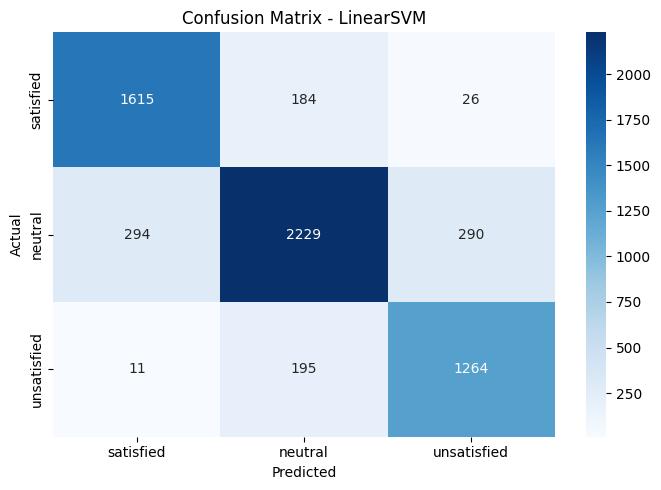

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=["satisfied", "neutral", "unsatisfied"])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["satisfied", "neutral", "unsatisfied"],
    yticklabels=["satisfied", "neutral", "unsatisfied"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()